In [16]:
!pip install yfinance
!pip install numpy pandas matplotlib seaborn scipy plotly --quiet

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

In [20]:
# Example portfolio
tickers = ["AAPL", "MSFT", "GOOG", "AMZN"]
weights = np.array([0.25, 0.25, 0.25, 0.25])

start_date = "2015-01-01"
confidence_level = 0.95
risk_free_rate = 0.02
num_simulations = 10000

In [22]:
data = yf.download(tickers, start=start_date)
data = data.dropna()
data.tail()


[*********************100%***********************]  4 of 4 completed


Price            Close                                            High  \
Ticker            AAPL        AMZN        GOOG        MSFT        AAPL   
Date                                                                     
2026-02-23  266.179993  205.270004  311.690002  384.470001  269.429993   
2026-02-24  272.140015  208.559998  310.920013  389.000000  274.890015   
2026-02-25  274.230011  210.639999  313.029999  400.600006  274.940002   
2026-02-26  272.950012  207.919998  307.149994  401.720001  276.109985   
2026-02-27  264.179993  210.000000  311.429993  392.739990  272.809998   

Price                                                  Low              \
Ticker            AMZN        GOOG        MSFT        AAPL        AMZN   
Date                                                                     
2026-02-23  208.429993  319.454987  395.359985  263.380005  203.110001   
2026-02-24  210.360001  312.369995  389.359985  267.709991  203.250000   
2026-02-25  211.589996  313.660004  401.470001  271.049988  208.929993   
2026-02-26  211.050003  313.000000  407.489990  270.799988  205.350006   
2026-02-27  210.330002  312.079987  396.820007  262.890015  205.199997   

Price                                     Open                          \
Ticker            GOOG        MSFT        AAPL        AMZN        GOOG   
Date                                                                     
2026-02-23  309.989990  383.100006  263.489990  208.100006  319.140015   
2026-02-24  306.089996  381.709991  267.859985  205.470001  310.640015   
2026-02-25  309.359985  390.160004  271.779999  210.460007  312.119995   
2026-02-26  302.410004  398.739990  274.950012  210.729996  312.804993   
2026-02-27  303.591003  389.880005  272.809998  206.830002  303.940002   

Price                     Volume                                
Ticker            MSFT      AAPL      AMZN      GOOG      MSFT  
Date                                                            
2026-02-23  395.000000  37308200  53581500  17641200  43238300  
2026-02-24  384.140015  47014600  41137200  15040700  33884700  
2026-02-25  390.529999  33714300  41346400  20209100  43625500  
2026-02-26  404.709991  32345100  47756800  22380000  34405900  
2026-02-27  390.880005  72239400  57230900  33312100  51276300

In [24]:
returns = data['Close'].pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

portfolio_returns = returns.dot(weights)

In [26]:
portfolio_mean = np.dot(weights, mean_returns)
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

annual_return = portfolio_mean * 252
annual_volatility = portfolio_volatility * np.sqrt(252)

print("Annual Return:", round(annual_return,4))
print("Annual Volatility:", round(annual_volatility,4))

Annual Return: 0.263
Annual Volatility: 0.2487


In [27]:
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
print("Sharpe Ratio:", round(sharpe_ratio,4))



Sharpe Ratio: 0.977


In [28]:
downside_returns = portfolio_returns[portfolio_returns < 0]
downside_std = downside_returns.std() * np.sqrt(252)

sortino_ratio = (annual_return - risk_free_rate) / downside_std
print("Sortino Ratio:", round(sortino_ratio,4))

Sortino Ratio: 1.3207


In [30]:
VaR_hist = np.percentile(portfolio_returns, (1 - confidence_level) * 100)
print("Historical VaR (95%):", round(VaR_hist,4))

Historical VaR (95%): -0.0253


In [32]:
from scipy.stats import norm

z_score = norm.ppf(1 - confidence_level)
VaR_param = portfolio_mean + z_score * portfolio_volatility

print("Parametric VaR (95%):", round(VaR_param,4))

Parametric VaR (95%): -0.0247


In [34]:
CVaR = portfolio_returns[portfolio_returns <= VaR_hist].mean()
print("CVaR (Expected Shortfall):", round(CVaR,4))

CVaR (Expected Shortfall): -0.0364


In [36]:
cumulative = (1 + portfolio_returns).cumprod()
rolling_max = cumulative.cummax()
drawdown = cumulative / rolling_max - 1
max_drawdown = drawdown.min()

print("Maximum Drawdown:", round(max_drawdown,4))

Maximum Drawdown: -0.3903


In [38]:
market = yf.download("^GSPC", start=start_date)["Close"]
market_returns = market.pct_change().dropna()

aligned_data = pd.concat([portfolio_returns, market_returns], axis=1).dropna()
aligned_data.columns = ["Portfolio", "Market"]

cov_pm = np.cov(aligned_data["Portfolio"], aligned_data["Market"])[0][1]
var_market = np.var(aligned_data["Market"])

beta = cov_pm / var_market
print("Portfolio Beta:", round(beta,4))

[*********************100%***********************]  1 of 1 completed

Portfolio Beta: 1.1742


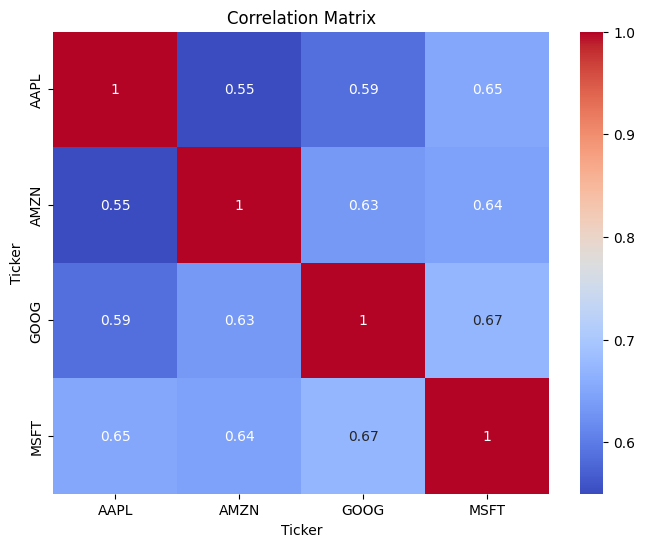

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()